In [ ]:
import pandas as pd
import numpy as np
import joblib

model = joblib.load("models/wind_model.pkl")
print("Model loaded ✅")

Model loaded ✅


In [ ]:
sample = pd.DataFrame([{
    "Wspd": 8.5,    # Wind speed m/s
    "Wdir": 180.0,  # Wind direction degrees
    "Etmp": 15.0,   # External temp °C
    "Itmp": 30.0,   # Internal temp °C
    "Ndir": 175.0,  # Nacelle direction degrees
    "Pab1": 2.1,    # Blade pitch angles
    "Pab2": 2.1,
    "Pab3": 2.1,
    "Prtv": 10.5,   # Rotor speed
    "yaw_error": 5.0  # our engineered feature
}])

prediction = model.predict(sample)
print(f"Predicted Power Output: {prediction[0]:.2f} kW")

Predicted Power Output: 1029.32 kW


In [ ]:
wind_speeds = [3, 5, 7, 9, 11, 13, 15]
print(f"{'Wind Speed (m/s)':<20} {'Predicted Power (kW)'}")
print("-" * 40)

for ws in wind_speeds:
    test = pd.DataFrame([{
        "Wspd": ws, "Wdir": 180.0, "Etmp": 15.0, "Itmp": 30.0,
        "Ndir": 180.0, "Pab1": 2.0, "Pab2": 2.0, "Pab3": 2.0,
        "Prtv": 10.0, "yaw_error": 0.0
    }])
    pred = model.predict(test)[0]
    print(f"{ws:<20} {pred:.2f}")

Wind Speed (m/s)     Predicted Power (kW)
----------------------------------------
3                    64.63
5                    292.40
7                    662.48
9                    1117.44
11                   1385.72
13                   1417.05
15                   1417.05


In [4]:
print("=== Model Summary ===")
print(f"Model Type     : Random Forest Regressor")
print(f"No. of Trees   : {model.n_estimators}")
print(f"Max Depth      : {model.max_depth}")
print(f"Features used  : {model.n_features_in_}")
print(f"Feature names  : {list(model.feature_names_in_)}")

=== Model Summary ===
Model Type     : Random Forest Regressor
No. of Trees   : 100
Max Depth      : 10
Features used  : 10
Feature names  : ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv', 'yaw_error']


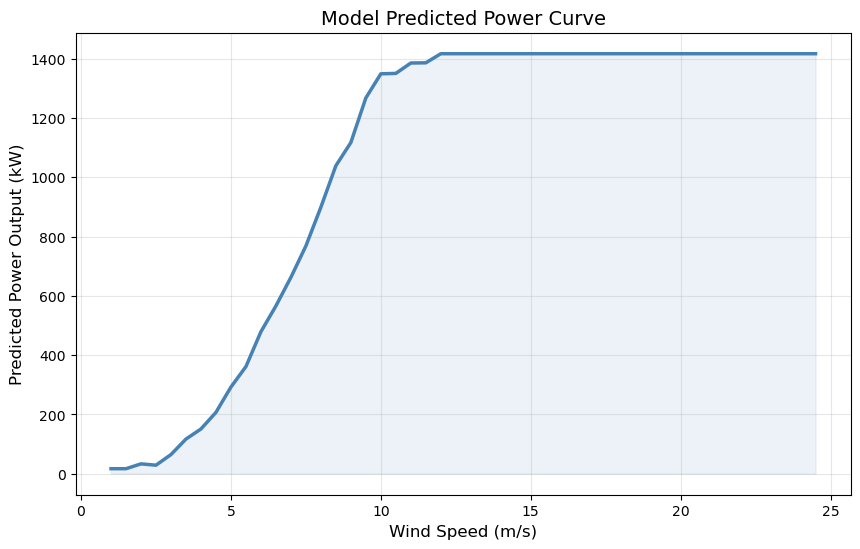

Power curve saved ✅


In [7]:
import matplotlib.pyplot as plt
import numpy as np

wind_speeds = np.arange(1, 25, 0.5)
predictions = []

for ws in wind_speeds:
    test = pd.DataFrame([{
        "Wspd": ws, "Wdir": 180.0, "Etmp": 15.0, "Itmp": 30.0,
        "Ndir": 180.0, "Pab1": 2.0, "Pab2": 2.0, "Pab3": 2.0,
        "Prtv": 10.0, "yaw_error": 0.0
    }])
    predictions.append(model.predict(test)[0])

plt.figure(figsize=(10, 6))
plt.plot(wind_speeds, predictions, color='steelblue', linewidth=2.5)
plt.fill_between(wind_speeds, predictions, alpha=0.1, color='steelblue')
plt.xlabel("Wind Speed (m/s)", fontsize=12)
plt.ylabel("Predicted Power Output (kW)", fontsize=12)
plt.title("Model Predicted Power Curve", fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig("05_predicted_power_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Power curve saved ✅")